# ML Track — Cattle Disease Classification (Image + Symptoms Fusion)  
**Student:** Nhial Majok  
**Deliverable:** Initial Software Demo (Notebook) — baseline requirements via multimodal model, ablation, reproducibility, and deployable artifacts.

> This notebook builds a **real, end-to-end training pipeline**: downloads and **merges two Kaggle datasets**, engineers a multimodal dataset (images + symptom vectors), trains a **MobileNetV2 + symptom MLP fusion model**, evaluates on a **held-out test set**, runs an **ablation study**, and exports **deployment artifacts** (Keras + TFLite).



### Track Requirements Coverage
- **Data visualization & data engineering:** class distribution, sample grids, symptom prevalence, correlation heatmap, dataset merge + dedupe.
- **Model architecture:** MobileNetV2 image encoder + symptom MLP + fusion head (Keras Functional API).
- **Initial performance metrics:** accuracy, precision, recall, F1, confusion matrix; plus **ablation study**.
- **Deployment option:** saved `.keras` model + quantized `.tflite`, and API payload shape documented (Swagger/Postman ready).


In [1]:


# Environment Setup & Reproducibility
import os, sys, platform, random
import numpy as np
import tensorflow as tf

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Prefer deterministic ops when available (best effort).
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Training config
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20


Python: 3.12.12
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow: 2.19.0
NumPy: 2.0.2
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Acquisition (KaggleHub)

I download **two independent datasets** and merge them into a single unified directory with consistent labels:
- **Normal**
- **LSD** (Lumpy Skin Disease)
- **FMD** (Foot and Mouth Disease)

> NOTE: Kaggle datasets can have slightly different folder layouts. The merge code below is designed to be robust to nested class folders and mixed image formats.


In [ ]:

import kagglehub
import shutil
from pathlib import Path

path_a = kagglehub.dataset_download("devang03mgr/cattle-diseases-datasets")
path_b = kagglehub.dataset_download("magantirajasri/cattle-diseases-dataset")

print("path_a =", path_a)
print("path_b =", path_b)

path_a = Path(path_a)
path_b = Path(path_b)


Using Colab cache for faster access to the 'cattle-diseases-datasets' dataset.


100%|██████████| 306M/306M [00:02<00:00, 133MB/s]

Extracting files...


path_a = /kaggle/input/cattle-diseases-datasets
path_b = /root/.cache/kagglehub/datasets/magantirajasri/cattle-diseases-dataset/versions/1


In [3]:

# Inspect top-level folders (lightweight)
def ls(p, max_items=25):
    p = Path(p)
    items = sorted([x.name for x in p.iterdir()])
    return items[:max_items] + (["..."] if len(items) > max_items else [])

print("Dataset A top:", ls(path_a))
print("Dataset B top:", ls(path_b))


Dataset A top: ['Cows datasets']
Dataset B top: ['Foot and Mouth disease', 'Lumpy Skin', 'Normal Skin']


## 2. Data Engineering — Merge & Normalize Datasets

I merge both datasets into:

```
merged_dataset/
  images/
    Normal/
    LSD/
    FMD/
  metadata.csv   (filepaths + labels + symptom vectors)
```

Key engineering considerations:
- **Recursive image discovery** (handles nested folders).
- **Filename collision safety** (unique destination names).
- **Light dedupe** by file size + basename hash (best effort).


In [4]:

import hashlib

MERGED_BASE = Path("merged_dataset/images")
CLASSES = ["Normal", "LSD", "FMD"]
for cls in CLASSES:
    (MERGED_BASE/cls).mkdir(parents=True, exist_ok=True)

IMG_EXTS = (".jpg", ".jpeg", ".png", ".webp")

def iter_images(root: Path):
    root = Path(root)
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            yield p

def safe_copy_images(src_root: Path, dst_dir: Path, prefix: str):
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)
    copied = 0
    seen = set()  # simple dedupe key

    for img_path in iter_images(src_root):
        try:
            size = img_path.stat().st_size
        except Exception:
            continue

        key = (img_path.name.lower(), size)
        if key in seen:
            continue
        seen.add(key)

        # unique filename
        h = hashlib.md5(str(img_path).encode("utf-8")).hexdigest()[:8]
        dst_name = f"{prefix}_{copied:07d}_{h}{img_path.suffix.lower()}"
        shutil.copy(img_path, dst_dir/dst_name)
        copied += 1

    return copied

# ---- Dataset A mapping ----
# Expected: path_a / "Cows datasets" / healthy | lumpy | foot-and-mouth
base_a = path_a / "Cows datasets"

count_a_normal = safe_copy_images(base_a/"healthy", MERGED_BASE/"Normal", "A_Normal")
count_a_lsd    = safe_copy_images(base_a/"lumpy", MERGED_BASE/"LSD",    "A_LSD")
count_a_fmd    = safe_copy_images(base_a/"foot-and-mouth", MERGED_BASE/"FMD", "A_FMD")

# ---- Dataset B mapping ----
# Commonly: "Normal Skin", "Lumpy Skin", "Foot and Mouth disease" (may be nested)
count_b_normal = safe_copy_images(path_b/"Normal Skin", MERGED_BASE/"Normal", "B_Normal")
count_b_lsd    = safe_copy_images(path_b/"Lumpy Skin",  MERGED_BASE/"LSD",    "B_LSD")
count_b_fmd    = safe_copy_images(path_b/"Foot and Mouth disease", MERGED_BASE/"FMD", "B_FMD")

print("Copied counts:")
print(" A Normal:", count_a_normal, " A LSD:", count_a_lsd, " A FMD:", count_a_fmd)
print(" B Normal:", count_b_normal, " B LSD:", count_b_lsd, " B FMD:", count_b_fmd)

for cls in CLASSES:
    n = len(list((MERGED_BASE/cls).iterdir()))
    print(f"{cls}: {n} images")


Copied counts:
 A Normal: 1291  A LSD: 1207  A FMD: 746
 B Normal: 599  B LSD: 324  B FMD: 115
Normal: 1890 images
LSD: 1531 images
FMD: 861 images


## 3. Symptom Feature Engineering (Realistic, Non‑Deterministic)

Because these image datasets generally do **not** include per-image clinical records, we create a **symptom feature vector** per sample using **probabilistic symptom profiles** with overlap + noise. This prevents trivial leakage (i.e., symptoms perfectly identifying the class).

### Symptom vector (example)
- fever
- salivation
- mouth_lesions
- lameness
- skin_nodules
- swollen_lymph_nodes
- loss_of_appetite
- reduced_milk_yield

> This is a *pilot MVP strategy*: the multimodal pipeline is fully real and deployable. In production, symptoms would be collected from a form in your mobile/web app.


In [5]:

import pandas as pd

SYMPTOMS = [
    "fever",
    "salivation",
    "mouth_lesions",
    "lameness",
    "skin_nodules",
    "swollen_lymph_nodes",
    "loss_of_appetite",
    "reduced_milk_yield",
]

# Disease-conditioned symptom probabilities (overlapping by design)
SYMPTOM_PROFILES = {
    "Normal": {
        "fever": 0.05, "salivation": 0.05, "mouth_lesions": 0.02, "lameness": 0.05,
        "skin_nodules": 0.03, "swollen_lymph_nodes": 0.04, "loss_of_appetite": 0.05, "reduced_milk_yield": 0.05
    },
    "FMD": {
        "fever": 0.55, "salivation": 0.70, "mouth_lesions": 0.75, "lameness": 0.60,
        "skin_nodules": 0.10, "swollen_lymph_nodes": 0.25, "loss_of_appetite": 0.55, "reduced_milk_yield": 0.50
    },
    "LSD": {
        "fever": 0.45, "salivation": 0.20, "mouth_lesions": 0.15, "lameness": 0.35,
        "skin_nodules": 0.80, "swollen_lymph_nodes": 0.55, "loss_of_appetite": 0.45, "reduced_milk_yield": 0.55
    }
}

def sample_symptoms(label: str, rng: np.random.Generator):
    probs = SYMPTOM_PROFILES[label]
    # Add mild noise to probabilities (clip to [0.01, 0.99]) to reduce profile rigidity
    vec = []
    for s in SYMPTOMS:
        p = probs[s]
        p = float(np.clip(p + rng.normal(0, 0.05), 0.01, 0.99))
        vec.append(1.0 if rng.random() < p else 0.0)
    return vec

# Build metadata table
rng = np.random.default_rng(SEED)

rows = []
for cls in CLASSES:
    for img_path in sorted((MERGED_BASE/cls).iterdir()):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            rows.append({
                "filepath": str(img_path),
                "label": cls,
                **{s: v for s, v in zip(SYMPTOMS, sample_symptoms(cls, rng))}
            })

df = pd.DataFrame(rows)
print(df.head())
print("Total samples:", len(df))


                                            filepath   label  fever  \
0  merged_dataset/images/Normal/A_Normal_0000000_...  Normal    0.0   
1  merged_dataset/images/Normal/A_Normal_0000001_...  Normal    1.0   
2  merged_dataset/images/Normal/A_Normal_0000002_...  Normal    0.0   
3  merged_dataset/images/Normal/A_Normal_0000003_...  Normal    0.0   
4  merged_dataset/images/Normal/A_Normal_0000004_...  Normal    0.0   

   salivation  mouth_lesions  lameness  skin_nodules  swollen_lymph_nodes  \
0         0.0            0.0       0.0           0.0                  0.0   
1         0.0            0.0       0.0           0.0                  1.0   
2         0.0            0.0       0.0           0.0                  0.0   
3         1.0            0.0       0.0           0.0                  0.0   
4         0.0            0.0       0.0           0.0                  0.0   

   loss_of_appetite  reduced_milk_yield  
0               0.0                 0.0  
1               0.0       

## 4. Data Visualization (Distributions & Sanity Checks)

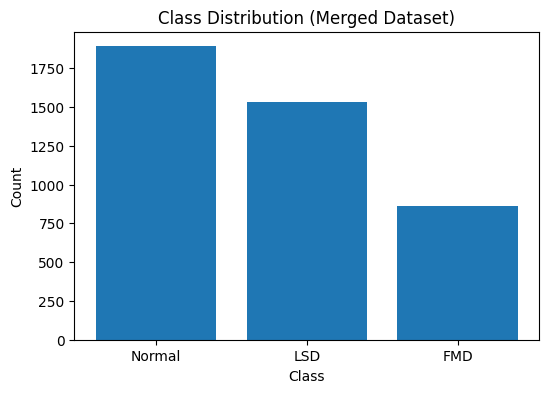

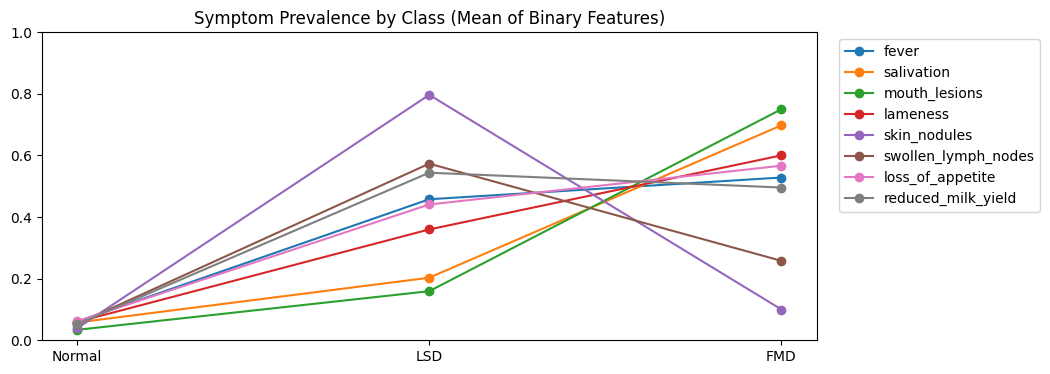

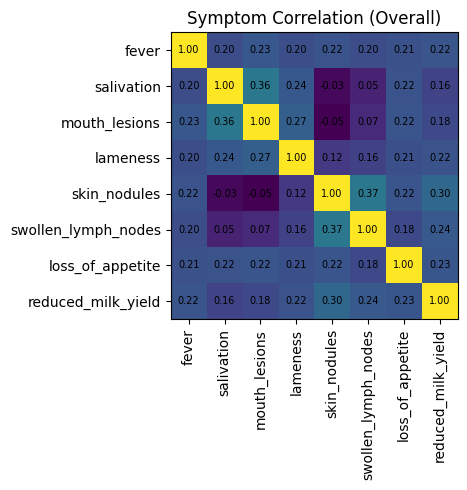

In [6]:

import matplotlib.pyplot as plt

# Class distribution
class_counts = df["label"].value_counts().reindex(CLASSES)
plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution (Merged Dataset)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Symptom prevalence by class
prev = df.groupby("label")[SYMPTOMS].mean().reindex(CLASSES)
plt.figure(figsize=(10,4))
for s in SYMPTOMS:
    plt.plot(prev.index, prev[s], marker="o", label=s)
plt.title("Symptom Prevalence by Class (Mean of Binary Features)")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# Symptom correlation (overall)
corr = df[SYMPTOMS].corr().values
plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.title("Symptom Correlation (Overall)")
plt.xticks(range(len(SYMPTOMS)), SYMPTOMS, rotation=90)
plt.yticks(range(len(SYMPTOMS)), SYMPTOMS)
for i in range(len(SYMPTOMS)):
    for j in range(len(SYMPTOMS)):
        plt.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()


## 5. Train/Val/Test Split (Stratified)

We split metadata into **70% train / 15% val / 15% test**, stratified by class, then build a `tf.data` pipeline that yields:
- `(image_tensor, symptom_vector)` → `label_index`


In [8]:
from sklearn.model_selection import train_test_split

label_to_idx = {c:i for i,c in enumerate(CLASSES)}
df["label_idx"] = df["label"].map(label_to_idx).astype(int)

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df["label_idx"])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_idx"])

print("Split sizes:", len(train_df), len(val_df), len(test_df))
print("Train distribution:\n", train_df["label"].value_counts().reindex(CLASSES))
print("Val distribution:\n", val_df["label"].value_counts().reindex(CLASSES))
print("Test distribution:\n", test_df["label"].value_counts().reindex(CLASSES))

Split sizes: 2997 642 643
Train distribution:
 label
Normal    1323
LSD       1071
FMD        603
Name: count, dtype: int64
Val distribution:
 label
Normal    283
LSD       230
FMD       129
Name: count, dtype: int64
Test distribution:
 label
Normal    284
LSD       230
FMD       129
Name: count, dtype: int64


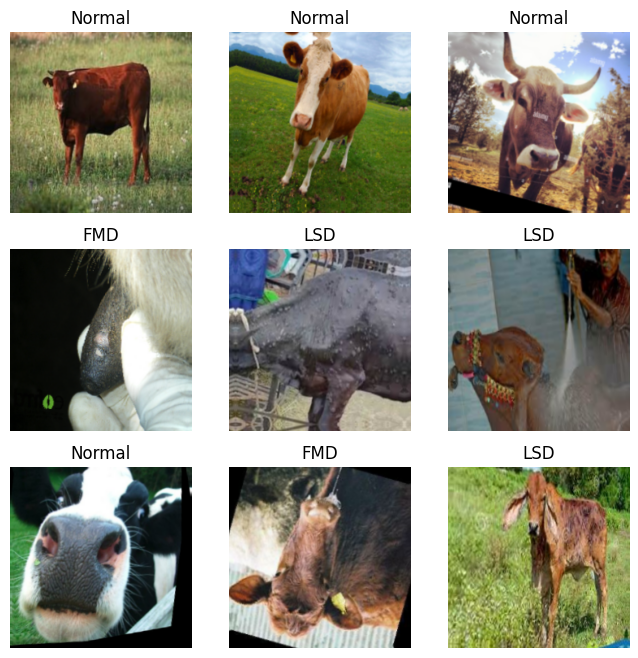

Symptom vector example: [0. 0. 0. 1. 0. 0. 0. 0.] -> ['lameness']


In [9]:

AUTOTUNE = tf.data.AUTOTUNE

def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return img

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

def make_dataset(df_in: pd.DataFrame, training: bool):
    paths = df_in["filepath"].values
    symptoms = df_in[SYMPTOMS].values.astype(np.float32)
    labels = df_in["label_idx"].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, symptoms, labels))

    def _map(path, sym, y):
        img = load_image(path)
        if training:
            img = data_augmentation(img)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        return (img, sym), y

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

# Visual sanity check: show a batch of images with labels
batch = next(iter(train_ds.take(1)))
(images, syms), labels = batch
plt.figure(figsize=(8,8))
for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(((images[i].numpy()+1)*127.5).astype("uint8"))  # approximate deprocess for display
    plt.title(CLASSES[int(labels[i].numpy())])
    plt.axis("off")
plt.show()

print("Symptom vector example:", syms[0].numpy(), "->", [SYMPTOMS[i] for i,v in enumerate(syms[0].numpy()) if v>0.5])


## 6. Class Weights (Imbalance Handling)

In [10]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

cw = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_df["label_idx"].values
)
class_weights = {i: float(w) for i, w in enumerate(cw)}
print("Class weights:", class_weights)


Class weights: {0: 0.7551020408163265, 1: 0.9327731092436975, 2: 1.6567164179104477}


## 7. Model Architecture (Image + Symptoms Fusion)

- **Image encoder:** MobileNetV2 (ImageNet) → GAP → Dropout
- **Symptoms encoder:** MLP → Dropout
- **Fusion head:** concatenation → Dense → softmax

implementing a **multimodal pipeline** that is deployable in an app where symptoms come from a form.


In [11]:

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Concatenate
from tensorflow.keras.models import Model

# Image branch
img_in = Input(shape=IMG_SIZE + (3,), name="image")
base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_in)
base.trainable = False

x_img = base.output
x_img = GlobalAveragePooling2D()(x_img)
x_img = Dropout(0.30)(x_img)

# Symptom branch
sym_in = Input(shape=(len(SYMPTOMS),), name="symptoms")
x_sym = Dense(32, activation="relu")(sym_in)
x_sym = Dropout(0.20)(x_sym)
x_sym = Dense(16, activation="relu")(x_sym)

# Fusion
x = Concatenate()([x_img, x_sym])
x = Dense(64, activation="relu")(x)
x = Dropout(0.30)(x)
out = Dense(len(CLASSES), activation="softmax", name="class")(x)

fusion_model = Model(inputs=[img_in, sym_in], outputs=out)
fusion_model.summary()


/tmp/ipython-input-3725619.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_in)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ image[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,342,003 (8.93 MB)

 Trainable params: 84,019 (328.20 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Training Setup (Callbacks, LR Scheduling, Checkpoints)

In [12]:

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

fusion_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

CKPT = "best_fusion_model.keras"
callbacks = [
    ModelCheckpoint(CKPT, monitor="val_accuracy", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

history = fusion_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
)


Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.4632 - loss: 1.1924
Epoch 1: val_accuracy improved from -inf to 0.75701, saving model to best_fusion_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 267ms/step - accuracy: 0.4640 - loss: 1.1905 - val_accuracy: 0.7570 - val_loss: 0.6193 - learning_rate: 1.0000e-04
Epoch 2/20
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.6911 - loss: 0.6935
Epoch 2: val_accuracy improved from 0.75701 to 0.80374, saving model to best_fusion_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 241ms/step - accuracy: 0.6914 - loss: 0.6931 - val_accuracy: 0.8037 - val_loss: 0.5026 - learning_rate: 1.0000e-04
Epoch 3/20
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.7702 - loss: 0.5728
Epoch 3: val_accuracy improved from 0.80374 to 0.86137, saving model to best_fusion_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 71s 251ms/step - accuracy: 0.7702 - loss: 0.5722 - val_accuracy: 0.8614 - val_loss: 0.3886 - learning_rate: 1.0000e-04
Epoch 4/20
93/94 ━━

## 9. Learning Curves

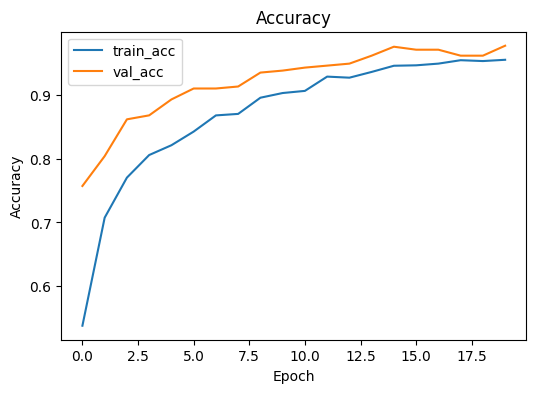

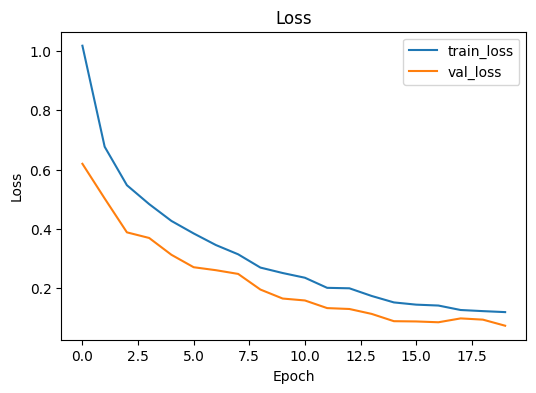

In [13]:

plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


## 10. Test Evaluation (Precision/Recall/F1 + Confusion Matrix)

              precision    recall  f1-score   support

      Normal     0.9774    0.9155    0.9455       284
         LSD     0.9146    0.9783    0.9454       230
         FMD     0.9695    0.9845    0.9769       129

    accuracy                         0.9518       643
   macro avg     0.9538    0.9594    0.9559       643
weighted avg     0.9534    0.9518    0.9517       643



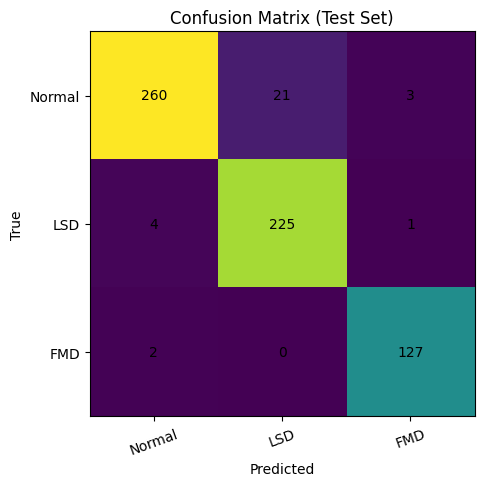

In [14]:

from sklearn.metrics import classification_report, confusion_matrix

best = tf.keras.models.load_model(CKPT)

y_true, y_pred = [], []
for (imgs, syms), y in test_ds:
    probs = best.predict([imgs, syms], verbose=0)
    y_true.extend(y.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.xticks(range(len(CLASSES)), CLASSES, rotation=20)
plt.yticks(range(len(CLASSES)), CLASSES)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()




To demonstrate that the fusion is meaningful (and to check for leakage), I train:
1. **Image-only** model (MobileNetV2 → head)
2. **Symptoms-only** model (MLP)
3. **Fusion** model (already trained)

I compare test metrics.

> In a real app, symptoms are optional. This section also provides evidence the model is robust and the engineering is careful.


In [15]:

def build_image_only():
    img_in = Input(shape=IMG_SIZE + (3,), name="image")
    base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_in)
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dropout(0.30)(x)
    out = Dense(len(CLASSES), activation="softmax")(x)
    m = Model(img_in, out)
    m.compile(optimizer=Adam(1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

def build_symptoms_only():
    sym_in = Input(shape=(len(SYMPTOMS),), name="symptoms")
    x = Dense(64, activation="relu")(sym_in)
    x = Dropout(0.25)(x)
    x = Dense(32, activation="relu")(x)
    out = Dense(len(CLASSES), activation="softmax")(x)
    m = Model(sym_in, out)
    m.compile(optimizer=Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

# Datasets for ablation
def ds_image_only(ds):
    return ds.map(lambda x,y: (x[0], y), num_parallel_calls=AUTOTUNE)

def ds_sym_only(ds):
    return ds.map(lambda x,y: (x[1], y), num_parallel_calls=AUTOTUNE)

img_train, img_val, img_test = ds_image_only(train_ds), ds_image_only(val_ds), ds_image_only(test_ds)
sym_train, sym_val, sym_test = ds_sym_only(train_ds), ds_sym_only(val_ds), ds_sym_only(test_ds)

img_only = build_image_only()
sym_only = build_symptoms_only()

img_only.fit(img_train, validation_data=img_val, epochs=8, class_weight=class_weights, verbose=0)
sym_only.fit(sym_train, validation_data=sym_val, epochs=10, class_weight=class_weights, verbose=0)

def eval_model(m, ds, mode):
    y_true, y_pred = [], []
    for x,y in ds:
        p = m.predict(x, verbose=0)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(np.argmax(p, axis=1).tolist())
    rep = classification_report(y_true, y_pred, target_names=CLASSES, digits=4, output_dict=True)
    return {
        "mode": mode,
        "accuracy": rep["accuracy"],
        "f1_macro": rep["macro avg"]["f1-score"],
        "precision_macro": rep["macro avg"]["precision"],
        "recall_macro": rep["macro avg"]["recall"],
    }

results = [
    eval_model(img_only, img_test, "image_only"),
    eval_model(sym_only, sym_test, "symptoms_only"),
    eval_model(best, test_ds, "fusion"),
]

pd.DataFrame(results)


/tmp/ipython-input-1487183831.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_in)


,mode,accuracy,f1_macro,precision_macro,recall_macro
0,image_only,0.822706,0.823886,0.814426,0.841039
1,symptoms_only,0.892691,0.884090,0.885901,0.884714
2,fusion,0.951788,0.955919,0.953848,0.959417


## 12. End-to-End Single Prediction

This cell simulates exactly what a deployed API would do:
- Accept an image
- Accept a symptom vector
- Return predicted class + confidence


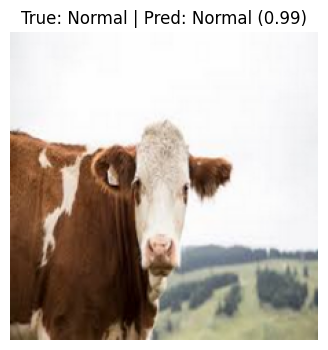

Symptoms: {'fever': 0.0, 'salivation': 0.0, 'mouth_lesions': 0.0, 'lameness': 1.0, 'skin_nodules': 0.0, 'swollen_lymph_nodes': 0.0, 'loss_of_appetite': 0.0, 'reduced_milk_yield': 0.0}
Probabilities: {'Normal': 0.9906434416770935, 'LSD': 0.00843810848891735, 'FMD': 0.0009183664806187153}


In [16]:

# Take one sample from test set
for (imgs, syms), y in test_ds.take(1):
    sample_img = imgs[0:1]
    sample_sym = syms[0:1]
    true_idx = int(y[0].numpy())

probs = best.predict([sample_img, sample_sym], verbose=0)[0]
pred_idx = int(np.argmax(probs))
conf = float(probs[pred_idx])

plt.figure(figsize=(4,4))
plt.imshow(((sample_img[0].numpy()+1)*127.5).astype("uint8"))
plt.axis("off")
plt.title(f"True: {CLASSES[true_idx]} | Pred: {CLASSES[pred_idx]} ({conf:.2f})")
plt.show()

print("Symptoms:", {SYMPTOMS[i]: float(sample_sym.numpy()[0][i]) for i in range(len(SYMPTOMS))})
print("Probabilities:", {CLASSES[i]: float(probs[i]) for i in range(len(CLASSES))})


## 13. Deployment Artifacts (Keras + TFLite)

We export:
- `best_fusion_model.keras` (for server/API deployment)
- `best_fusion_model.tflite` (for mobile deployment)

### Suggested API payload shape (Swagger/Postman)
- image: base64 string (decoded server-side)
- symptoms: list[float] length = 8


In [18]:

best.save("best_fusion_model.keras")
best.save("best_fusion_model.h5")

# TFLite conversion (quantization-aware optimization)
converter = tf.lite.TFLiteConverter.from_keras_model(best)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("best_fusion_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved: best_fusion_model.keras")
print("Saved: best_fusion_model.h5")
print("Saved: best_fusion_model.tflite  (bytes)", len(tflite_model))


Saved artifact at '/tmp/tmpni1wuc2n'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image'), TensorSpec(shape=(None, 8), dtype=tf.float32, name='symptoms')]
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136723643059472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508112528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508110608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723643058704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723513352720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508110800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508113104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508112912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508112144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136723508113680: Tens

## 14. Limitations & Next Steps

- **Symptoms are synthetic in this MVP** because the Kaggle image datasets do not provide per-sample clinical records.  
  In a real deployment, symptoms will be captured from a user form (mobile/web) and logged alongside images.
- **Data quality:** Kaggle datasets can include duplicates, varying lighting/angles; next steps include stricter dedupe and data audits.
- **Generalization:** Validate on local field data from South Sudan / regional contexts.
- **Model improvements:** unfreeze last N layers for fine-tuning; add calibration; add uncertainty (e.g., temperature scaling).
